# 🩺 Diabetes Prediction — Deep Learning (ANN)

This notebook builds an **Artificial Neural Network (ANN)** using TensorFlow/Keras to predict
whether a patient is diabetic or not.

**Dataset features used (same as the Flask app):**
- `gender`, `age`, `hypertension`, `heart_disease`, `bmi`, `HbA1c_level`, `blood_glucose_level`

**Target:** `diabetes` (0 = Not Diabetic, 1 = Diabetic)

## Step 1 — Import Libraries

In [1]:
# Standard data-science stack
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_auc_score)

# TensorFlow / Keras — Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility seed
np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow version: {tf.__version__}')

TensorFlow version: 2.20.0


## Step 2 — Load & Explore the Dataset

In [2]:
# Load the CSV (place diabetes.csv in the same folder as this notebook)
df = pd.read_csv('diabetes.csv')

print('Shape:', df.shape)
df.head()

Shape: (99982, 8)


,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,25.19,6.6,140,0
1,0,54.0,0,0,27.32,6.6,80,0
2,1,28.0,0,0,27.32,5.7,158,0
3,0,36.0,0,0,23.45,5.0,155,0
4,1,76.0,1,1,20.14,4.8,155,0


In [3]:
# Basic info: data types, null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99982 entries, 0 to 99981
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               99982 non-null  int64  
 1   age                  99982 non-null  float64
 2   hypertension         99982 non-null  int64  
 3   heart_disease        99982 non-null  int64  
 4   bmi                  99982 non-null  float64
 5   HbA1c_level          99982 non-null  float64
 6   blood_glucose_level  99982 non-null  int64  
 7   diabetes             99982 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 6.1 MB


In [4]:
# Summary statistics
df.describe()

,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,99982.000000,99982.000000,99982.000000,99982.000000,99982.000000,99982.000000,99982.000000,99982.000000
mean,0.414375,41.888076,0.074863,0.039427,27.320757,5.527529,138.057810,0.085015
std,0.492616,22.517206,0.263172,0.194610,6.636853,1.070665,40.709469,0.278906
min,0.000000,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,0.000000,24.000000,0.000000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,0.000000,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,1.000000,60.000000,0.000000,0.000000,29.580000,6.200000,159.000000,0.000000
max,1.000000,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


Target distribution:
diabetes
0    91482
1     8500
Name: count, dtype: int64


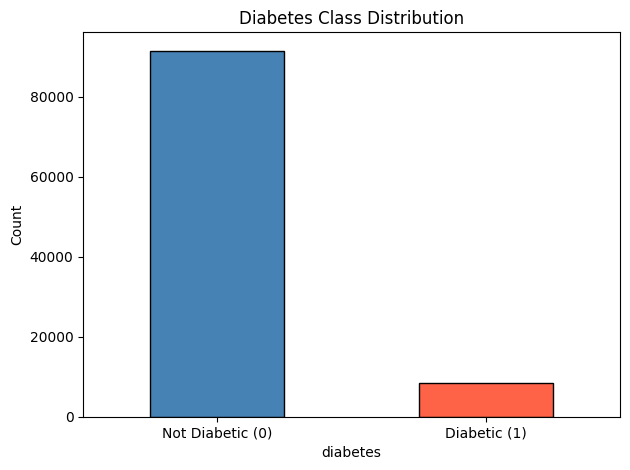

In [5]:
# Check class balance
print('Target distribution:')
print(df['diabetes'].value_counts())

df['diabetes'].value_counts().plot(kind='bar', color=['steelblue','tomato'], edgecolor='black')
plt.title('Diabetes Class Distribution')
plt.xticks([0,1], ['Not Diabetic (0)', 'Diabetic (1)'], rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Step 3 — Preprocessing

In [6]:
# --- 3a. Handle missing values ---
print('Missing values per column:')
print(df.isnull().sum())

# Fill any numeric NaNs with the column median (safe for skewed data)
for col in df.select_dtypes(include=[np.number]).columns:
    df[col].fillna(df[col].median(), inplace=True)

print('\nMissing values after fill:', df.isnull().sum().sum())

Missing values per column:
gender                 0
age                    0
hypertension           0
heart_disease          0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Missing values after fill: 0


In [7]:
# --- 3b. Encode the 'gender' column (Male=1, Female=0) ---
# The Flask app already maps gender to 0/1 before prediction,
# so we replicate that exact mapping here.
if df['gender'].dtype == object:
    df['gender'] = df['gender'].str.lower().map({'male': 1, 'female': 0, 'other': 0})

print('Gender value counts after encoding:')
print(df['gender'].value_counts())

Gender value counts after encoding:
gender
0    58552
1    41430
Name: count, dtype: int64


In [8]:
# --- 3c. Handle 'smoking_history' if present (drop it; not used by Flask app) ---
# The Flask app only uses 7 features; drop any extras to stay compatible.
FEATURES = ['gender', 'age', 'hypertension', 'heart_disease',
            'bmi', 'HbA1c_level', 'blood_glucose_level']
TARGET   = 'diabetes'

# Keep only the required columns
df = df[FEATURES + [TARGET]]
print('Kept features:', FEATURES)
df.head()

Kept features: ['gender', 'age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']


,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,25.19,6.6,140,0
1,0,54.0,0,0,27.32,6.6,80,0
2,1,28.0,0,0,27.32,5.7,158,0
3,0,36.0,0,0,23.45,5.0,155,0
4,1,76.0,1,1,20.14,4.8,155,0


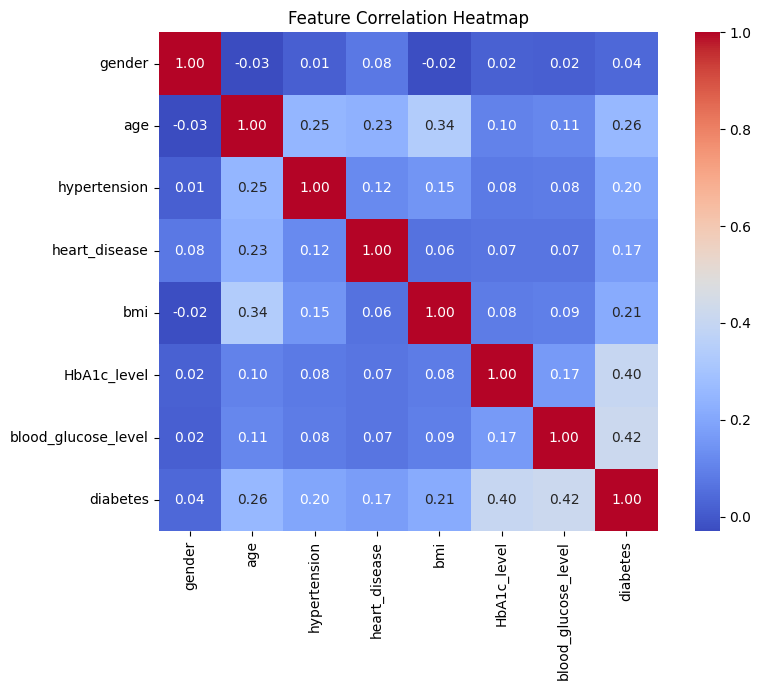

In [9]:
# --- 3d. Correlation heatmap ---
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [10]:
# --- 3e. Split into features (X) and target (y) ---
X = df[FEATURES].values
y = df[TARGET].values

# Train / validation / test split  (70% | 15% | 15%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')

Train: (69987, 7)  Val: (14997, 7)  Test: (14998, 7)


In [11]:
# --- 3f. Feature scaling (StandardScaler) ---
# Neural networks converge much faster when features are on a similar scale.
# IMPORTANT: fit scaler ONLY on training data to prevent data leakage.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print('Scaling complete. Sample mean (should be ~0):', X_train.mean(axis=0).round(2))

Scaling complete. Sample mean (should be ~0): [-0.  0.  0.  0. -0.  0.  0.]


## Step 4 — Build the ANN Model

Architecture:
```
Input (7)  →  Dense(64, ReLU)  →  Dropout(0.3)
           →  Dense(32, ReLU)  →  Dropout(0.2)
           →  Dense(16, ReLU)
           →  Output Dense(1, Sigmoid)   → binary classification
```

In [12]:
def build_model(input_dim: int) -> keras.Model:
    """Create and compile an ANN for binary classification."""
    model = keras.Sequential([
        # --- Input layer ---
        layers.Input(shape=(input_dim,)),

        # --- Hidden layer 1: 64 neurons, ReLU activation ---
        # ReLU helps avoid vanishing-gradient problem.
        layers.Dense(64, activation='relu',
                     kernel_initializer='he_normal'),
        layers.BatchNormalization(),   # normalise activations for stable training
        layers.Dropout(0.3),           # randomly zero 30% of neurons → reduces overfitting

        # --- Hidden layer 2: 32 neurons ---
        layers.Dense(32, activation='relu',
                     kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        # --- Hidden layer 3: 16 neurons ---
        layers.Dense(16, activation='relu',
                     kernel_initializer='he_normal'),

        # --- Output layer: 1 neuron, Sigmoid → probability [0,1] ---
        layers.Dense(1, activation='sigmoid')
    ], name='diabetes_ann')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',   # standard loss for binary classification
        metrics=['accuracy']
    )
    return model


model = build_model(input_dim=X_train.shape[1])
model.summary()

Model: "diabetes_ann"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 192 (768.00 B)

## Step 5 — Train the Model

In [13]:
# EarlyStopping stops training when validation loss stops improving,
# and restores the best weights automatically.
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,           # wait 15 epochs before stopping
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/150
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9358 - loss: 0.1730 - val_accuracy: 0.9621 - val_loss: 0.1095
Epoch 2/150
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9542 - loss: 0.1273 - val_accuracy: 0.9641 - val_loss: 0.0993
Epoch 3/150
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9578 - loss: 0.1182 - val_accuracy: 0.9645 - val_loss: 0.0960
Epoch 4/150
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9602 - loss: 0.1120 - val_accuracy: 0.9656 - val_loss: 0.0931
Epoch 5/150
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9613 - loss: 0.1090 - val_accuracy: 0.9665 - val_loss: 0.0918
Epoch 6/150
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9618 - loss: 0.1064 - val_accuracy: 0.9675 - val_loss: 0.0911
Epoch 7/150
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9628 - loss: 0.1047 - val_accuracy: 0.9665 - val_loss: 0.0916
Epoch 8/150
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9627 - loss: 0

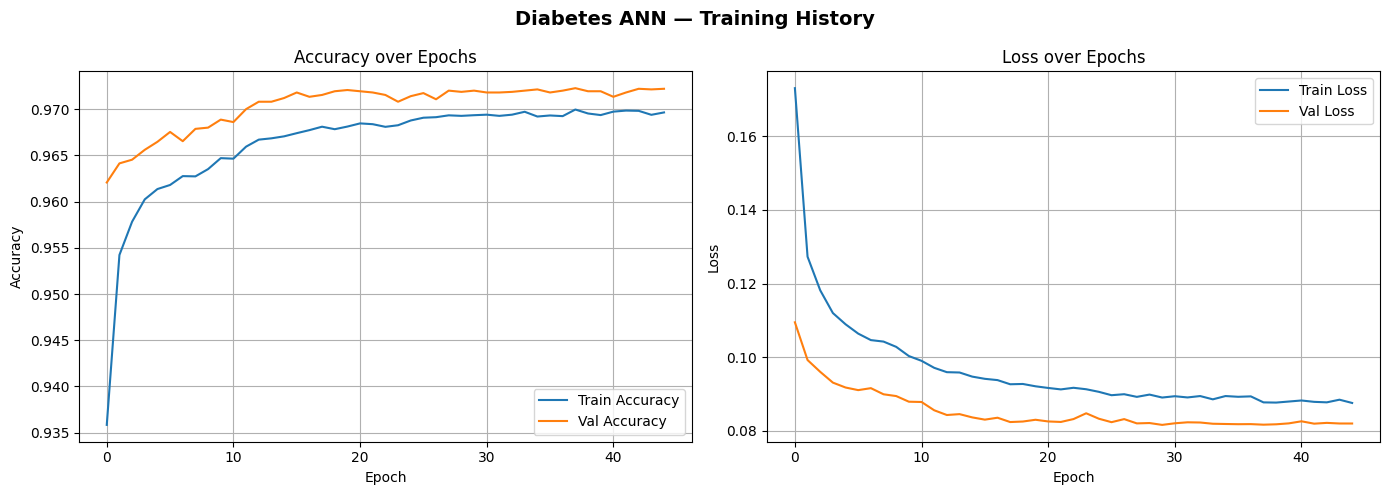

In [14]:
# --- Plot training curves ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True)

plt.suptitle('Diabetes ANN — Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 6 — Evaluate on Test Set

In [15]:
# Predict probabilities, then convert to 0/1 using 0.5 threshold
y_prob = model.predict(X_test).flatten()
y_pred = (y_prob >= 0.5).astype(int)

acc  = accuracy_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_prob)

print(f'Test Accuracy : {acc:.4f}  ({acc*100:.2f}%)')
print(f'ROC-AUC Score : {auc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Not Diabetic', 'Diabetic']))

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Test Accuracy : 0.9719  (97.19%)
ROC-AUC Score : 0.9773

Classification Report:
              precision    recall  f1-score   support

Not Diabetic       0.97      1.00      0.98     13723
    Diabetic       0.97      0.69      0.81      1275

    accuracy                           0.97     14998
   macro avg       0.97      0.84      0.90     14998
weighted avg       0.97      0.97      0.97     14998



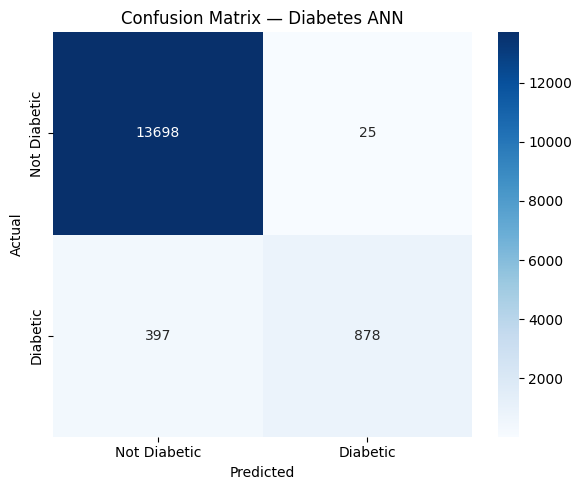

In [16]:
# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Diabetic', 'Diabetic'],
            yticklabels=['Not Diabetic', 'Diabetic'])
plt.title('Confusion Matrix — Diabetes ANN')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Step 7 — Save the Model & Scaler

We save both the trained model and the fitted scaler so the Flask app can load them directly instead of retraining every request.

In [17]:
import pickle, os

# Save Keras model (HDF5 format)
model.save('diabetes_ann_model.h5')
print('Model saved → diabetes_ann_model.h5')

# Save scaler (needed to preprocess new inputs identically)
with open('diabetes_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('Scaler saved → diabetes_scaler.pkl')

Model saved → diabetes_ann_model.h5
Scaler saved → diabetes_scaler.pkl


## Step 8 — Final Prediction Function

This function mirrors exactly what the Flask `/diabetes` route expects.
Call it with raw user inputs — no manual scaling needed.

In [18]:
def predict_diabetes(
    gender: str,          # 'male' or 'female'
    age: float,
    hypertension: int,    # 0 or 1
    heart_disease: int,   # 0 or 1
    bmi: float,
    hba1c_level: float,   # HbA1c %
    blood_glucose_level: float
) -> str:
    """
    Predicts whether a patient is diabetic.

    Parameters
    ----------
    gender              : 'male' or 'female'
    age                 : patient age in years
    hypertension        : 1 if patient has hypertension, else 0
    heart_disease       : 1 if patient has heart disease, else 0
    bmi                 : Body Mass Index
    hba1c_level         : HbA1c percentage (e.g., 5.5)
    blood_glucose_level : Blood glucose in mg/dL

    Returns
    -------
    str : 'Diabetic' or 'Not Diabetic'
    """
    # 1. Encode gender exactly as Flask does
    gender_val = 1 if gender.lower() == 'male' else 0

    # 2. Build input array in the same column order as training
    raw_input = np.array([[gender_val, age, hypertension, heart_disease,
                           bmi, hba1c_level, blood_glucose_level]],
                         dtype=float)

    # 3. Scale using the fitted scaler
    scaled_input = scaler.transform(raw_input)

    # 4. Predict probability
    prob = model.predict(scaled_input, verbose=0)[0][0]

    # 5. Apply threshold and return human-readable label
    label = 'Diabetic' if prob >= 0.5 else 'Not Diabetic'
    print(f'Prediction probability: {prob:.4f}  →  {label}')
    return label


# ── Demo: try a sample patient ──────────────────────────────────────────
result = predict_diabetes(
    gender='female',
    age=45,
    hypertension=1,
    heart_disease=0,
    bmi=32.5,
    hba1c_level=7.2,
    blood_glucose_level=180
)
print('Final Result:', result)

Prediction probability: 0.9998  →  Diabetic
Final Result: Diabetic


## Step 9 — How to Load Saved Model (for Flask Integration)

In your `app.py`, replace the `RandomForestClassifier` block with:

```python
import pickle
from tensorflow import keras

# Load once at startup
diabetes_model  = keras.models.load_model('diabetes_ann_model.h5')
diabetes_scaler = pickle.load(open('diabetes_scaler.pkl', 'rb'))

# Inside the /diabetes route:
scaled = diabetes_scaler.transform([[gender_val, age, hypertension,
                                     heart_disease, bmi, hba1c_level, glucose_level]])
prob   = diabetes_model.predict(scaled)[0][0]
prediction_text = 'Diabetic' if prob >= 0.5 else 'Not Diabetic'
```